In [1]:
#libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#loading the dataset 

data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
data.shape

(1470, 35)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
data["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

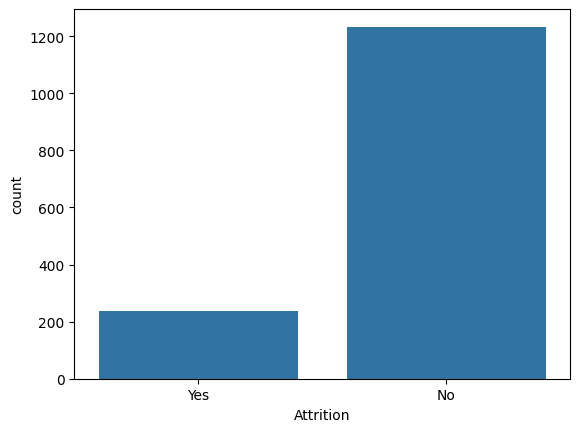

In [10]:
sns.countplot(x="Attrition", data=data)

Text(0.5, 1.0, 'Over time Vs Attrition')

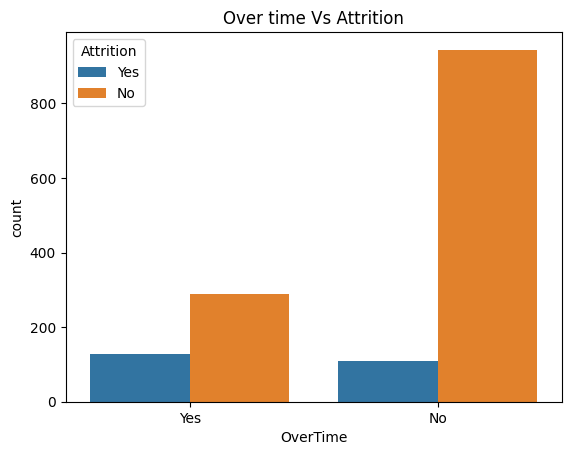

In [11]:
sns.countplot(x = "OverTime", hue="Attrition", data=data)
plt.title("Over time Vs Attrition")


Text(0.5, 1.0, 'JobSatisfaction Vs Attrition')

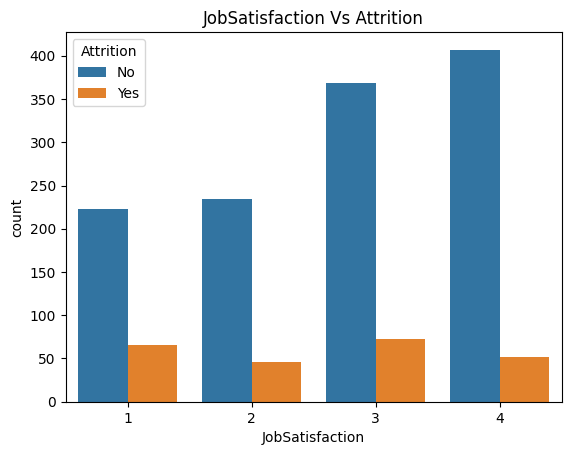

In [12]:
sns.countplot(x = "JobSatisfaction", hue="Attrition", data=data)
plt.title("JobSatisfaction Vs Attrition")


In [13]:
corr_matrix  =data.corr(numeric_only=True)

<Axes: >

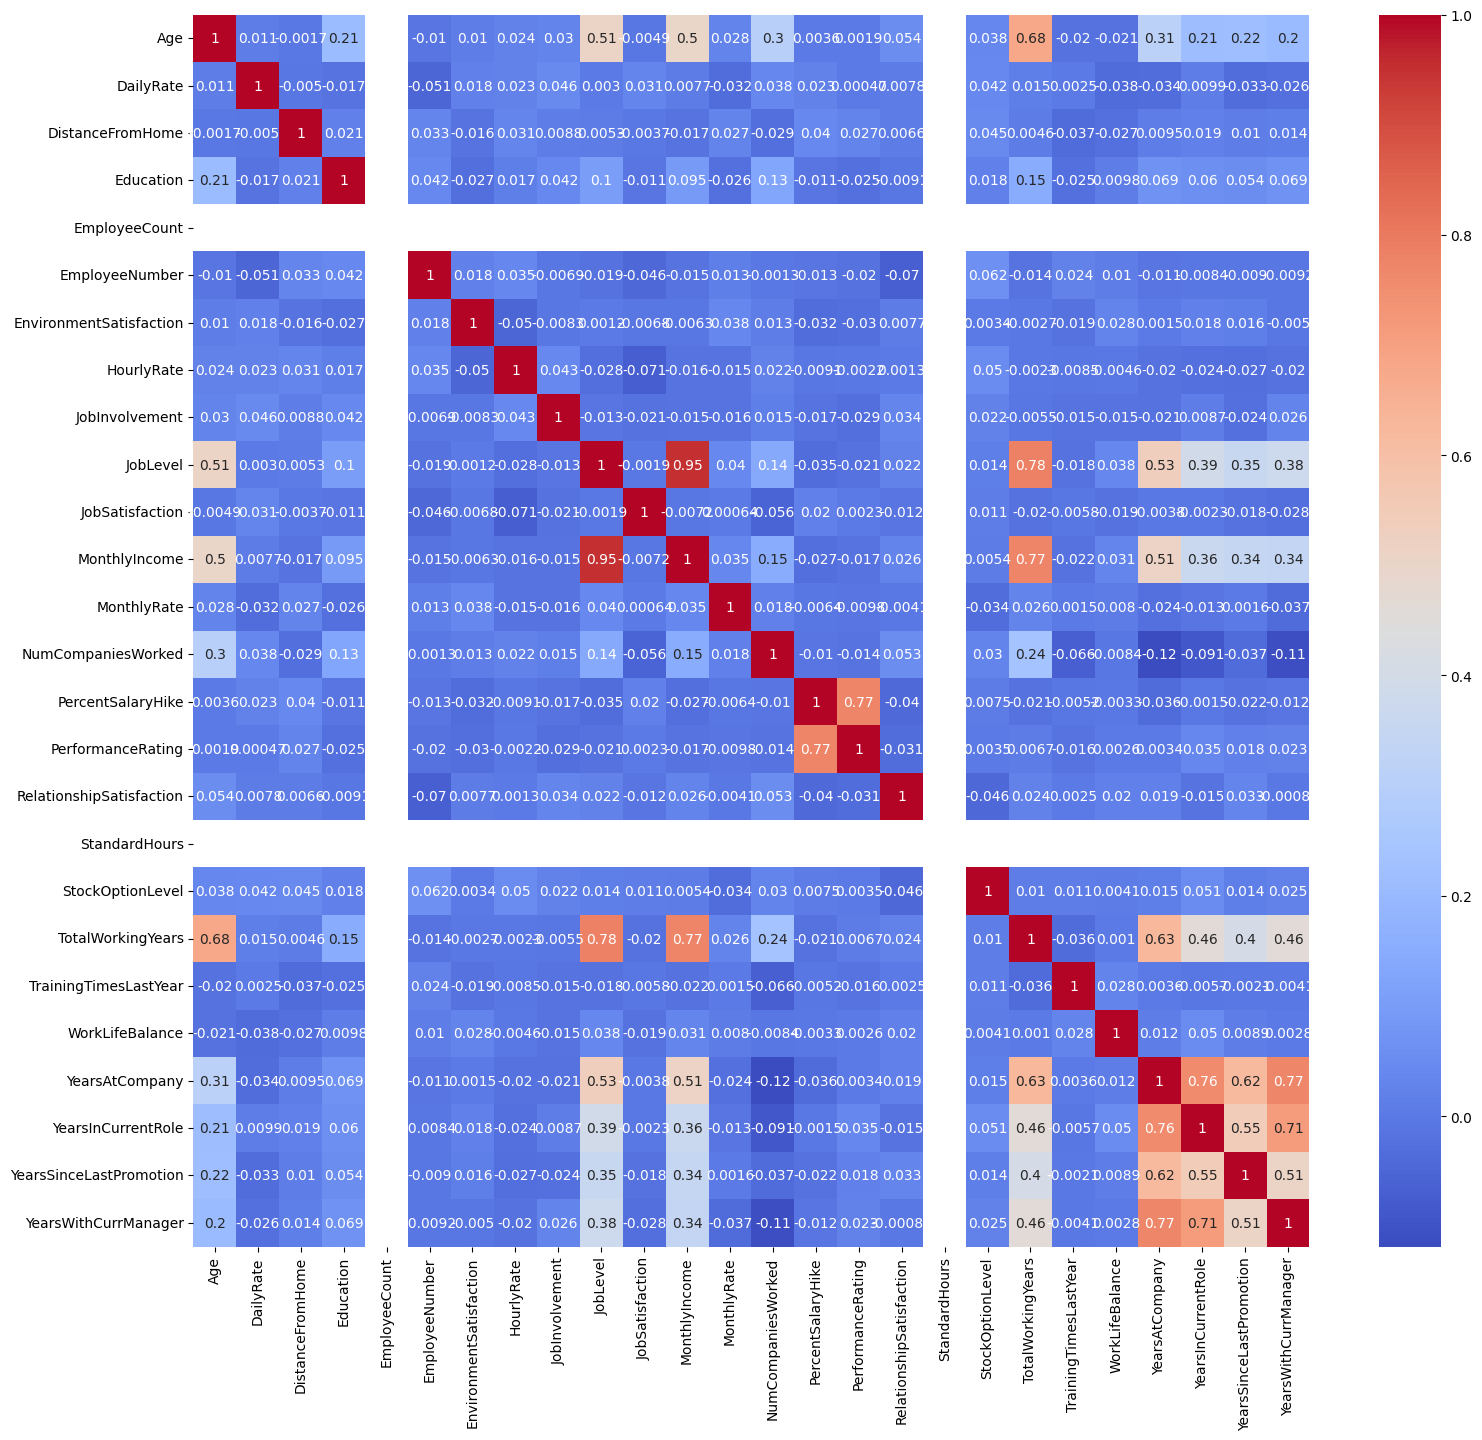

In [14]:
plt.figure(figsize=(18, 16)) 
sns.heatmap(corr_matrix ,  annot=True, cmap="coolwarm")

In [15]:
data = data.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

In [16]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [17]:
data.shape

(1470, 31)

In [18]:
print(data.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

In [19]:
data = data.copy()   # optional

le = LabelEncoder()

for col in data.select_dtypes(include="object").columns:
    data[col] = le.fit_transform(data[col])

In [20]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC" : SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42)
}

In [22]:
def Logistic_Regression(x_train, y_train):
    model = LogisticRegression(max_iter=1000)
    model.fit(x_train, y_train)
    return model

In [23]:
def DecisionTree_Classifier(x_train, y_train):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(x_train, y_train)
    return model

In [24]:
def RandomForest_Classifier(x_train, y_train):
    model = RandomForestClassifier(random_state=42)
    model.fit(x_train, y_train)
    return model

In [25]:
def SVC_(x_train, y_train):
    model = SVC()
    model.fit(x_train, y_train)
    return model

In [26]:
def KNeighbors_Classifier(x_train, y_train):
    model = KNeighborsClassifier()
    model.fit(x_train, y_train)
    return model

In [27]:
def GaussianNB_(x_train, y_train):
    model = GaussianNB()
    model.fit(x_train, y_train)
    return model

In [28]:
def XGBClassifier_(x_train, y_train):
    model = XGBClassifier()
    model.fit(x_train, y_train)
    return model

In [29]:
def build_and_train_model(data, target_name, clf_fn):

    # Features and Target
    X = data.drop(target_name, axis=1)
    y = data[target_name]

    # Train-Test Split
    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    # Feature Scaling
    scaler = StandardScaler()

    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    # Train Model
    model = clf_fn(x_train, y_train)

    # Training Accuracy
    train_pred = model.predict(x_train)
    train_acc = accuracy_score(y_train, train_pred)
    print("Training Accuracy:", train_acc)

    # Testing Accuracy
    y_pred = model.predict(x_test)
    test_acc = accuracy_score(y_test, y_pred)
    print("Testing Accuracy:", test_acc)

    # Confusion Matrix
    print("\nConfusion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Classification Report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return {
        "model": model,
        "scaler": scaler,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred
    }

Training Accuracy: 1.0
Testing Accuracy: 0.8809523809523809

Confusion Matrix
[[254   1]
 [ 34   5]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



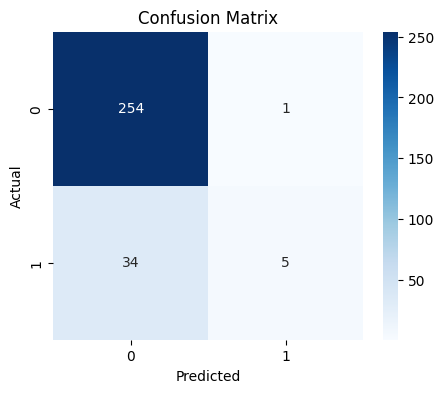

In [38]:
result_RF = build_and_train_model(data, "Attrition", RandomForest_Classifier)

Training Accuracy: 0.8698979591836735
Testing Accuracy: 0.8945578231292517

Confusion Matrix
[[249   6]
 [ 25  14]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



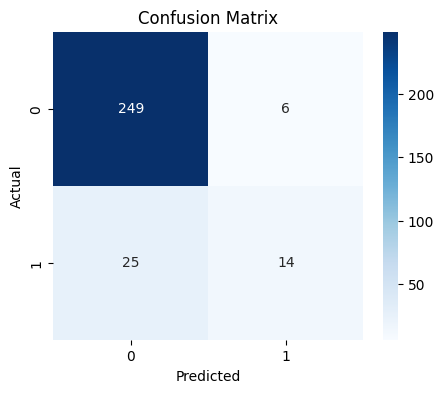

In [31]:
result_LR = build_and_train_model(data, "Attrition", Logistic_Regression)

Training Accuracy: 1.0
Testing Accuracy: 0.7993197278911565

Confusion Matrix
[[226  29]
 [ 30   9]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       255
           1       0.24      0.23      0.23        39

    accuracy                           0.80       294
   macro avg       0.56      0.56      0.56       294
weighted avg       0.80      0.80      0.80       294



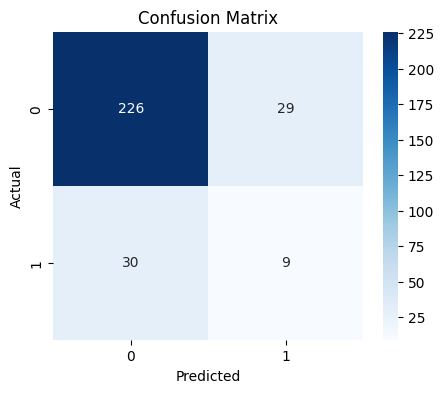

In [32]:
result_DC = build_and_train_model(data, "Attrition", DecisionTree_Classifier)

Training Accuracy: 1.0
Testing Accuracy: 0.8809523809523809

Confusion Matrix
[[254   1]
 [ 34   5]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



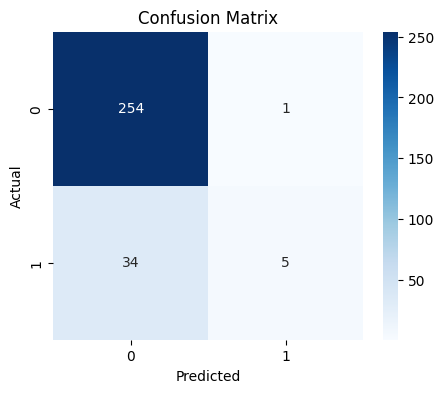

In [33]:
result_RC = build_and_train_model(data, "Attrition", RandomForest_Classifier)

Training Accuracy: 0.9183673469387755
Testing Accuracy: 0.8877551020408163

Confusion Matrix
[[255   0]
 [ 33   6]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       255
           1       1.00      0.15      0.27        39

    accuracy                           0.89       294
   macro avg       0.94      0.58      0.60       294
weighted avg       0.90      0.89      0.85       294



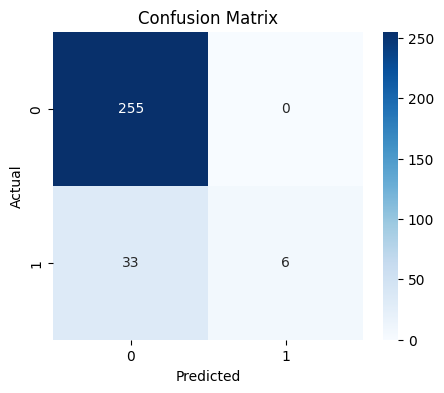

In [34]:
result_SVC = build_and_train_model(data, "Attrition", SVC_)

Training Accuracy: 0.8647959183673469
Testing Accuracy: 0.8605442176870748

Confusion Matrix
[[252   3]
 [ 38   1]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       255
           1       0.25      0.03      0.05        39

    accuracy                           0.86       294
   macro avg       0.56      0.51      0.49       294
weighted avg       0.79      0.86      0.81       294



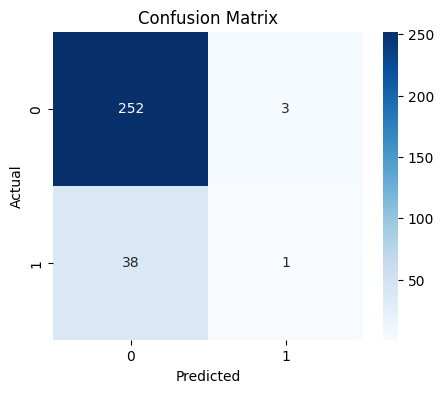

In [35]:
result_KNN = build_and_train_model(data, "Attrition", KNeighbors_Classifier)

Training Accuracy: 0.8001700680272109
Testing Accuracy: 0.8435374149659864

Confusion Matrix
[[225  30]
 [ 16  23]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       255
           1       0.43      0.59      0.50        39

    accuracy                           0.84       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.87      0.84      0.85       294



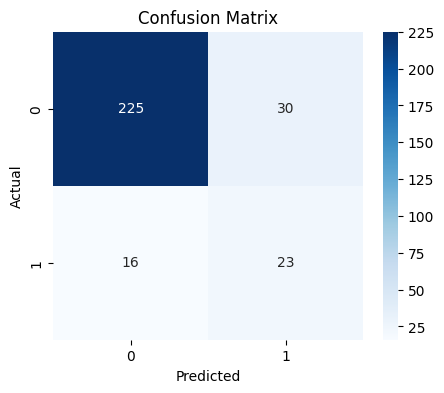

In [36]:
result_GNB = build_and_train_model(data, "Attrition", GaussianNB_)

Training Accuracy: 1.0
Testing Accuracy: 0.8707482993197279

Confusion Matrix
[[246   9]
 [ 29  10]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       255
           1       0.53      0.26      0.34        39

    accuracy                           0.87       294
   macro avg       0.71      0.61      0.64       294
weighted avg       0.85      0.87      0.85       294



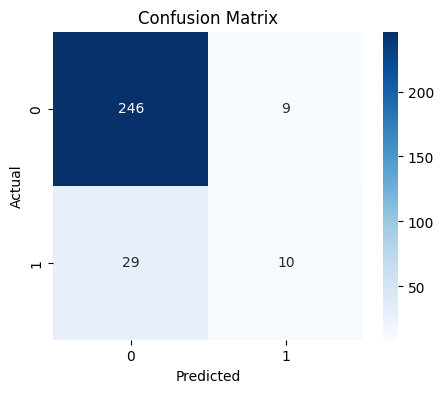

In [37]:
result_XGB = build_and_train_model(data, "Attrition", XGBClassifier_)

GridSearchCV

In [55]:
def get_param_grid(model_name):
    param_grids = {
        "LogisticRegression":{
            'C':[0.1, 1, 10],
            'solver':['lbfgs', 'liblinear']
        },
        "RandomForestClassifier":{
            'n_estimators':[100, 200],
            'max_depth':[5, 10, 15]
        },
        "DecisionTreeClassifier":{
            'max_depth':[3,5,10],
            'min_samples_split':[2,5,10]
        },
        "SVC":{
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }, 
        
         "KNN": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        },

        "XGBoost": {
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5, 7],
            "n_estimators": [100, 200]
        }
    }
    return param_grids[model_name]

In [62]:
#Generic tuning function

def tune_model(model, model_name, x_train, y_train, x_test, y_test):

    grid = GridSearchCV(
        estimator=model,
        param_grid=get_param_grid(model_name),
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(x_test)

    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print("Best Parameters :", grid.best_params_)
    print("Best CV Score   :", grid.best_score_)
    print("Test Accuracy   :", test_accuracy)
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "best_model": best_model,
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "test_accuracy": test_accuracy,
        "y_pred": y_pred,
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

In [63]:
best_rf = tune_model(
    RandomForestClassifier(random_state=42),
    "RandomForestClassifier",
    result_RF["x_train"],
    result_RF["y_train"]
)

TypeError: tune_model() missing 2 required positional arguments: 'x_test' and 'y_test'

In [58]:
best_svc = tune_model(
    SVC(random_state=42),
    "SVC",
    result_RF["x_train"],
    result_RF["y_train"]
)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.8588496213487199


In [61]:
y_pred = best_svc.predict(result_SVC["x_test"])

print("Test Accuracy:", accuracy_score(result_SVC["y_test"], y_pred))

Test Accuracy: 0.891156462585034
